In [39]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, f1_score, recall_score 

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, roc_auc_score
from xgboost import XGBClassifier

In [6]:
df = pd.read_csv("novagen_dataset.csv")

In [7]:
df.head()

,Age,BMI,Blood_Pressure,Cholesterol,Glucose_Level,Heart_Rate,Sleep_Hours,Exercise_Hours,Water_Intake,Stress_Level,...,Diet,MentalHealth,PhysicalActivity,MedicalHistory,Allergies,Diet_Type__Vegan,Diet_Type__Vegetarian,Blood_Group_AB,Blood_Group_B,Blood_Group_O
0,2.0,26.0,111.0,198.0,99.0,72.0,4.0,1.0,5.0,5.0,...,1,2,1,0,1,False,True,True,False,False
1,8.0,24.0,121.0,199.0,103.0,75.0,2.0,1.0,2.0,9.0,...,1,2,1,2,2,False,False,True,False,False
2,81.0,27.0,147.0,203.0,100.0,74.0,10.0,-0.0,5.0,1.0,...,2,0,0,1,0,True,False,False,False,False
3,25.0,21.0,150.0,199.0,102.0,70.0,7.0,3.0,3.0,3.0,...,1,2,1,2,0,True,False,False,True,False
4,24.0,26.0,146.0,202.0,99.0,76.0,10.0,2.0,5.0,1.0,...,2,0,2,0,2,False,True,False,True,False


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9549 entries, 0 to 9548
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    9549 non-null   float64
 1   BMI                    9549 non-null   float64
 2   Blood_Pressure         9549 non-null   float64
 3   Cholesterol            9549 non-null   float64
 4   Glucose_Level          9549 non-null   float64
 5   Heart_Rate             9549 non-null   float64
 6   Sleep_Hours            9549 non-null   float64
 7   Exercise_Hours         9549 non-null   float64
 8   Water_Intake           9549 non-null   float64
 9   Stress_Level           9549 non-null   float64
 10  Target                 9549 non-null   int64  
 11  Smoking                9549 non-null   int64  
 12  Alcohol                9549 non-null   int64  
 13  Diet                   9549 non-null   int64  
 14  MentalHealth           9549 non-null   int64  
 15  Phys

In [9]:
df.describe()

,Age,BMI,Blood_Pressure,Cholesterol,Glucose_Level,Heart_Rate,Sleep_Hours,Exercise_Hours,Water_Intake,Stress_Level,Target,Smoking,Alcohol,Diet,MentalHealth,PhysicalActivity,MedicalHistory,Allergies
count,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000
mean,33.806786,25.660697,130.382658,199.091528,100.225678,73.613782,6.951409,1.892345,3.580899,4.382134,0.521416,0.990470,0.995183,1.005864,0.998429,1.003351,1.004713,0.989318
std,24.566473,1.942369,27.878476,1.969234,2.157999,1.681538,2.352152,1.378714,1.622874,2.078593,0.499567,0.815521,0.816653,0.815877,0.821844,0.808800,0.813506,0.815699
min,0.000000,19.000000,22.000000,192.000000,93.000000,67.000000,0.000000,-0.000000,-0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,14.000000,24.000000,113.000000,198.000000,99.000000,73.000000,5.000000,1.000000,2.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,29.000000,26.000000,134.000000,199.000000,100.000000,74.000000,7.000000,2.000000,4.000000,4.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
75%,50.000000,27.000000,150.000000,200.000000,102.000000,75.000000,9.000000,3.000000,5.000000,6.000000,1.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000
max,100.000000,32.000000,225.000000,207.000000,107.000000,80.000000,14.000000,8.000000,10.000000,12.000000,1.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000


In [12]:
df.isnull().sum()

Age                      0
BMI                      0
Blood_Pressure           0
Cholesterol              0
Glucose_Level            0
Heart_Rate               0
Sleep_Hours              0
Exercise_Hours           0
Water_Intake             0
Stress_Level             0
Target                   0
Smoking                  0
Alcohol                  0
Diet                     0
MentalHealth             0
PhysicalActivity         0
MedicalHistory           0
Allergies                0
Diet_Type__Vegan         0
Diet_Type__Vegetarian    0
Blood_Group_AB           0
Blood_Group_B            0
Blood_Group_O            0
dtype: int64

In [13]:
df.duplicated().sum()

np.int64(0)

In [23]:
# Check target distribution

df['Target'].value_counts()

Target
1    4979
0    4570
Name: count, dtype: int64

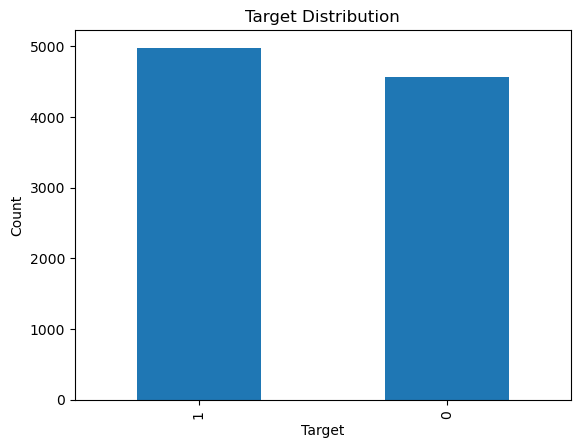

In [19]:
import matplotlib.pyplot as plt

df['Target'].value_counts().plot(kind='bar')
plt.xlabel('Target')
plt.ylabel('Count')
plt.title('Target Distribution')
plt.show()


In [31]:
# The dataset is well balanced the difference is only 4.2%

# EDA

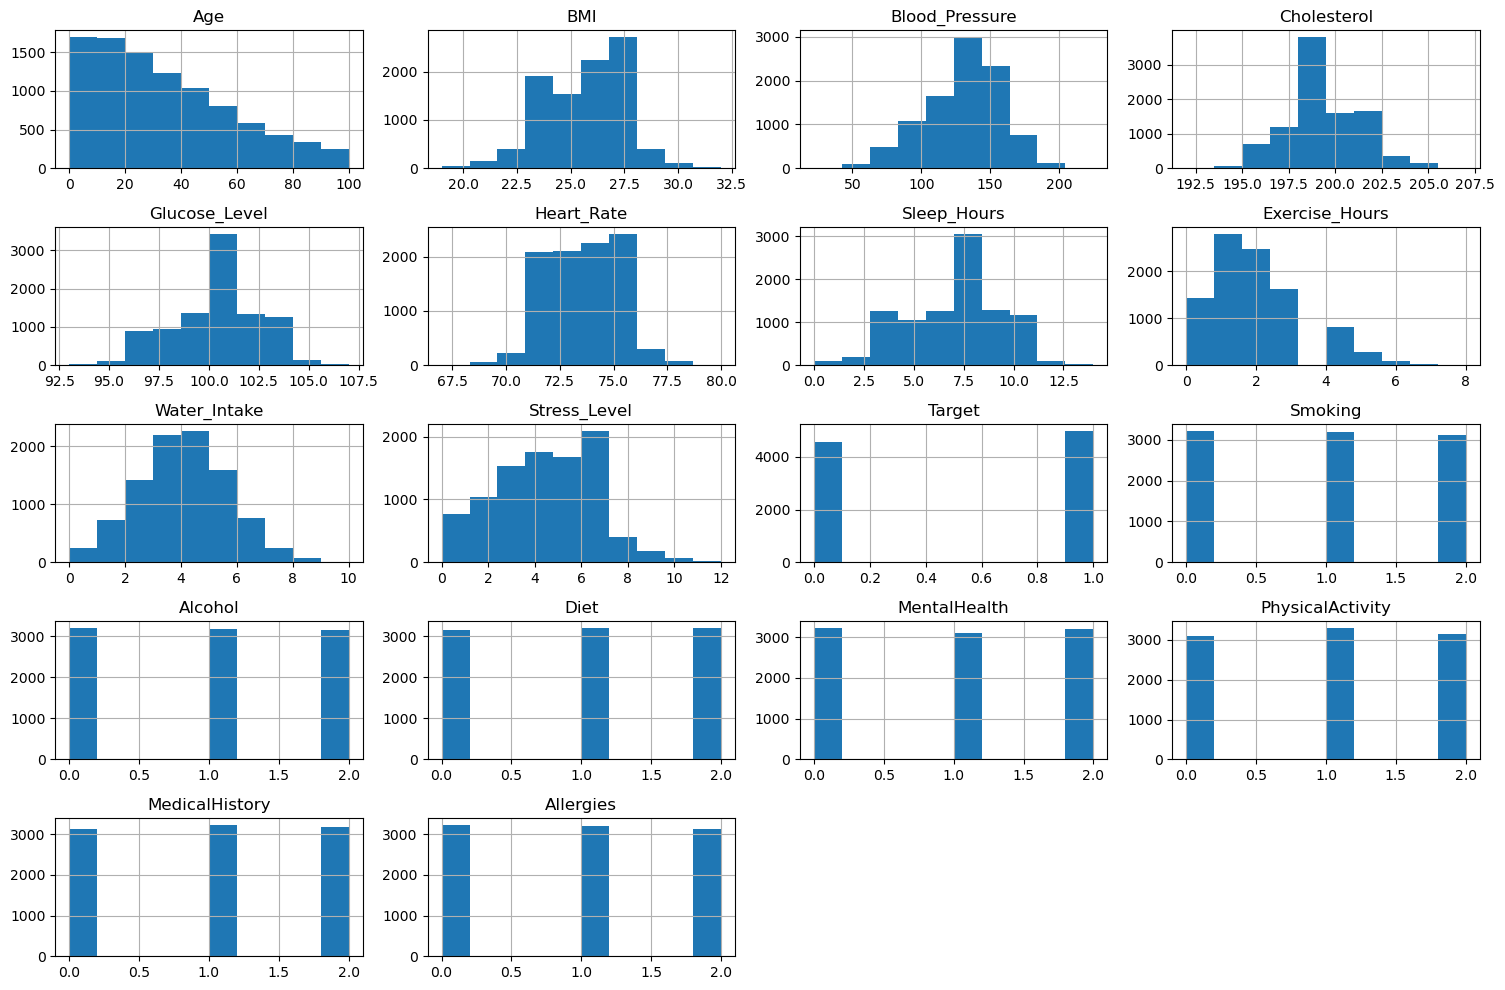

In [28]:

# ->distribution of each numerical feature
df.hist(figsize=(15,10))
plt.tight_layout()
plt.show()

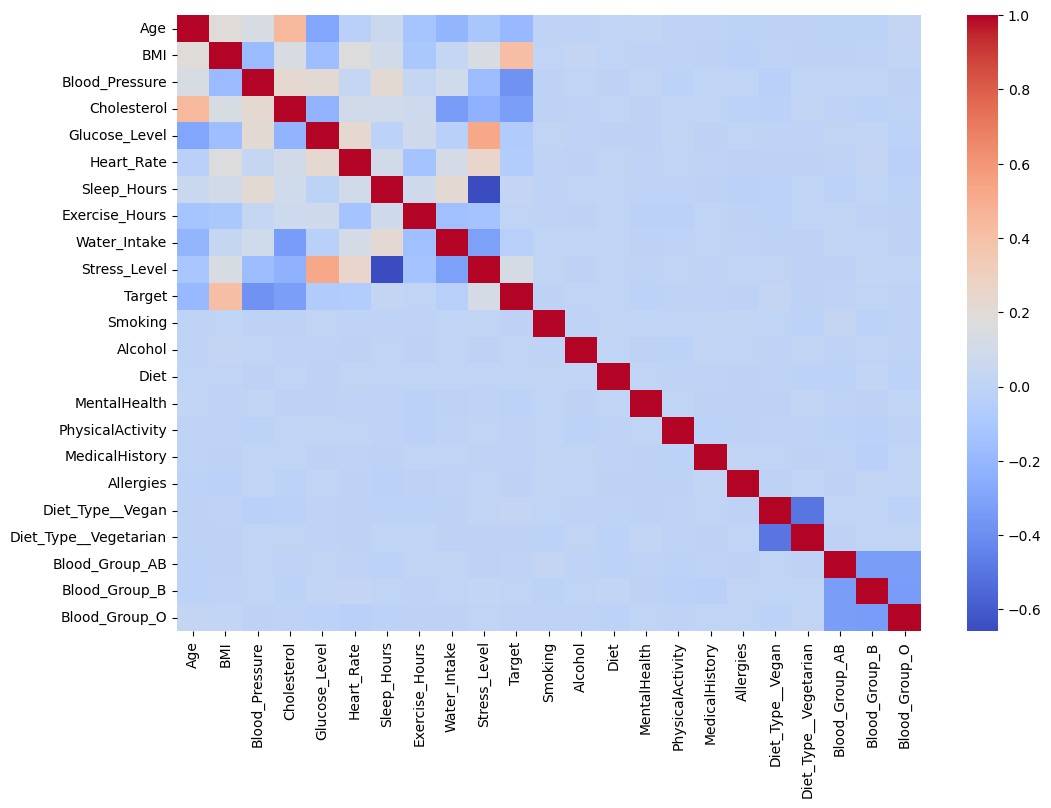

In [27]:
# correlation heat map
import seaborn as sns

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.show()

In [29]:
df.corr()['Target'].sort_values(ascending=False)

Target                   1.000000
BMI                      0.413972
Stress_Level             0.119455
Sleep_Hours              0.025931
Diet_Type__Vegan         0.023707
Exercise_Hours           0.008214
Blood_Group_B            0.007749
Diet                     0.005602
Alcohol                  0.003077
Blood_Group_AB           0.001174
MedicalHistory          -0.001666
PhysicalActivity        -0.002511
Blood_Group_O           -0.002728
Allergies               -0.004322
Diet_Type__Vegetarian   -0.005176
Smoking                 -0.005283
MentalHealth            -0.016372
Water_Intake            -0.038406
Heart_Rate              -0.065957
Glucose_Level           -0.072148
Age                     -0.190743
Cholesterol             -0.324361
Blood_Pressure          -0.380279
Name: Target, dtype: float64

In [30]:
# strong positive relationship = BMI
# weak positive relationship = Stress level
# strong negative relationships = BP, cholesterol, Age

# As BMI increases, the likelihood of belonging to Target=1 increases.
# Higher Blood Pressure tends to be associated with Target=0. --> unusual from medical perspective
# Higher Cholesterol tends to be associated with Target=0.  --> unusual from medical perspective

In [32]:
df.groupby('Target')[[
    'BMI',
    'Blood_Pressure',
    'Cholesterol',
    'Glucose_Level',
    'Stress_Level',
    'Age'
]].mean()

,BMI,Blood_Pressure,Cholesterol,Glucose_Level,Stress_Level,Age
Target,,,,,,
0,24.821444,141.447921,199.758206,100.388184,4.122976,38.697593
1,26.431010,120.226351,198.479614,100.076521,4.620004,29.317734


In [33]:
#  so based on the above observation, 0 - unhealthy, 1 - healthy

# Creating a baseline model

In [34]:
# Split features and Target

X = df.drop('Target', axis=1)
y = df['Target']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [35]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [40]:
# Logistic Regression (with regularization)


log_reg = LogisticRegression(
    penalty="l2",
    solver="liblinear",
    max_iter=1000
)

log_reg.fit(X_train_scaled, y_train)

y_pred_lr = log_reg.predict(X_test_scaled)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Logistic Regression Recall:", recall_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.8141361256544503
Logistic Regression Recall: 0.8283132530120482
              precision    recall  f1-score   support

           0       0.81      0.80      0.80       914
           1       0.82      0.83      0.82       996

    accuracy                           0.81      1910
   macro avg       0.81      0.81      0.81      1910
weighted avg       0.81      0.81      0.81      1910



In [41]:
# In Model Evaluation, Recall is more important than accuracy 
# because missing a high-risk patient is dangerous


# KNN Model

In [42]:
knn = KNeighborsClassifier(
    n_neighbors=5,
    metric="euclidean"
)

knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)

print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print("KNN Recall:", recall_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))

KNN Accuracy: 0.8832460732984293
KNN Recall: 0.8835341365461847
              precision    recall  f1-score   support

           0       0.87      0.88      0.88       914
           1       0.89      0.88      0.89       996

    accuracy                           0.88      1910
   macro avg       0.88      0.88      0.88      1910
weighted avg       0.88      0.88      0.88      1910



# Random Forest (Ensemble Learning)

In [43]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Random Forest Recall:", recall_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


Random Forest Accuracy: 0.9382198952879581
Random Forest Recall: 0.9588353413654619
              precision    recall  f1-score   support

           0       0.95      0.92      0.93       914
           1       0.93      0.96      0.94       996

    accuracy                           0.94      1910
   macro avg       0.94      0.94      0.94      1910
weighted avg       0.94      0.94      0.94      1910



In [44]:
# Which health indicators were most important for predicting health status.


importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance.head(10))

          Feature  Importance
1             BMI    0.209735
2  Blood_Pressure    0.158685
3     Cholesterol    0.108142
9    Stress_Level    0.085640
4   Glucose_Level    0.072369
6     Sleep_Hours    0.069404
0             Age    0.067378
5      Heart_Rate    0.049491
8    Water_Intake    0.048155
7  Exercise_Hours    0.026469


# Gradient Boosting (Ensemble Learning)

In [45]:
gb = GradientBoostingClassifier(
    n_estimators=150,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)

print("Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred_gb))
print("Gradient Boosting Recall:", recall_score(y_test, y_pred_gb))
print(classification_report(y_test, y_pred_gb))


Gradient Boosting Accuracy: 0.9303664921465968
Gradient Boosting Recall: 0.9497991967871486
              precision    recall  f1-score   support

           0       0.94      0.91      0.93       914
           1       0.92      0.95      0.93       996

    accuracy                           0.93      1910
   macro avg       0.93      0.93      0.93      1910
weighted avg       0.93      0.93      0.93      1910



# Voting Classifier (Ensemble Learning)

In [51]:
voting_clf = VotingClassifier(
    estimators=[
        ("lr", LogisticRegression(max_iter=1000, solver="liblinear")),
        ("knn", KNeighborsClassifier(n_neighbors=5)),
        ("rf", RandomForestClassifier(n_estimators=200, random_state=42))
    ],
    voting="soft"
)

voting_clf.fit(X_train_scaled, y_train)

y_pred_vote = voting_clf.predict(X_test_scaled)

print("Voting Classifier Accuracy:", accuracy_score(y_test, y_pred_vote))
print("Voting Classifier Recall:", recall_score(y_test, y_pred_vote))
print(classification_report(y_test, y_pred_vote))


Voting Classifier Accuracy: 0.9157068062827225
Voting Classifier Recall: 0.929718875502008
              precision    recall  f1-score   support

           0       0.92      0.90      0.91       914
           1       0.91      0.93      0.92       996

    accuracy                           0.92      1910
   macro avg       0.92      0.92      0.92      1910
weighted avg       0.92      0.92      0.92      1910



# Best Classifier that we should use for NovaGen(based on Recall) - Random Forest with accuracy of 93.7%

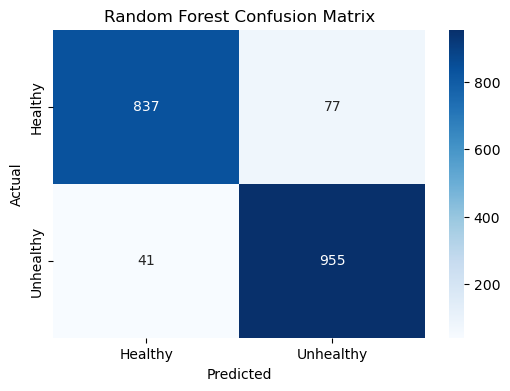

In [48]:
# confusion matrix for the best model

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Healthy','Unhealthy'],
    yticklabels=['Healthy','Unhealthy']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.show()

In [ ]:
# The confusion matrix shows that the Random Forest model correctly classified the majority of healthy and unhealthy individuals, with very few false negatives and false positives. This confirms the model's strong performance and supports its selection as the final classifier for NovaGen Research Labs.

In [49]:
# Model comparison table

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "KNN",
        "Random Forest",
        "Gradient Boosting",
        "Voting Classifier"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_gb),
        accuracy_score(y_test, y_pred_vote)
    ]
})

results.sort_values("Accuracy", ascending=False)

,Model,Accuracy
2,Random Forest,0.938220
3,Gradient Boosting,0.930366
4,Voting Classifier,0.915707
1,KNN,0.883246
0,Logistic Regression,0.814136


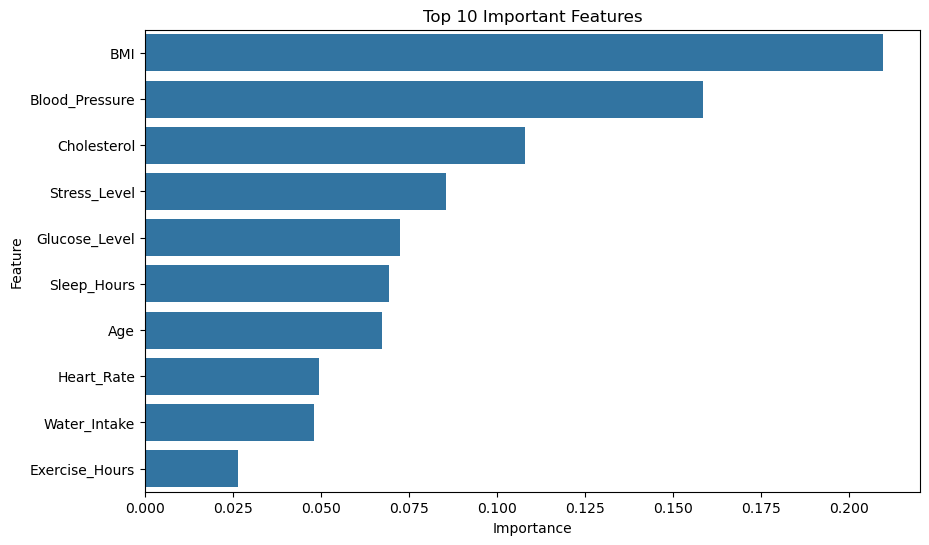

In [52]:
# Which health indicators contribute most to predicting health status - using plot
plt.figure(figsize=(10,6))
sns.barplot(
    data=importance.head(10),
    x="Importance",
    y="Feature"
)
plt.title("Top 10 Important Features")
plt.show()